In [1]:
import pandas as pd
import numpy as np
import torch
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import grad
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import trange
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')
import numpy as np

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
print("Device:", device)

Device: cuda:0


### Load Data

In [3]:
filename = 'OptionData.csv'
df = pd.read_csv(filename)
df.head()

,Vol,Spot,T,CallValue,CallDelta,CallGamma,CallTheta,CallVega,CallRho,PutValue,PutDelta,PutGamma,PutTheta,PutVega,PutRho
0,0.680514,186.600738,4.307459,123.610440,0.874486,7.833258e-04,-6.315583,79.951649,170.442793,37.009702,-1.255144e-01,7.833258e-04,-6.315583,79.951649,-260.303063
1,0.831512,160.023861,3.712993,107.540359,0.863145,8.547510e-04,-7.566873,67.577462,113.556028,47.516498,-1.368551e-01,8.547510e-04,-7.566873,67.577462,-257.743254
2,0.573235,145.506848,4.325777,80.222407,0.818773,1.519029e-03,-5.284063,79.749793,168.336206,34.715559,-1.812270e-01,1.519029e-03,-5.284063,79.749793,-264.241509
3,0.157122,160.886209,1.181271,60.903513,0.997948,2.362467e-04,-0.075482,1.134982,117.716569,0.017304,-2.052387e-03,2.362467e-04,-0.075482,1.134982,-0.410497
4,0.098693,183.300264,1.544350,83.300266,1.000000,6.548985e-08,-0.000011,0.000335,154.434882,0.000001,-2.837679e-07,6.548985e-08,-0.000011,0.000335,-0.000082


### Split Data

In [4]:
train_df = df[:-20000]
test_df = df[-20000:]

### Prepare the Training Data

In [5]:
def prepareData(data_df):
    
    call_dict ={'CallValue':'Value', 'CallDelta':'Delta', 'CallTheta':'Theta', 'CallVega':'Vega'}
    put_dict ={'PutValue':'Value', 'PutDelta':'Delta', 'PutTheta':'Theta', 'PutVega':'Vega'}
    
    # Need the true first order gradients for Sobolev training
    label_call = data_df[['CallValue', 'CallDelta', 'CallTheta', 'CallVega']].copy(deep=True)
    label_call.rename(columns=call_dict, inplace=True)
    label_put = data_df[['PutValue', 'PutDelta', 'PutTheta', 'PutVega']].copy(deep=True)
    label_put.rename(columns=put_dict, inplace=True)
    label_list = [label_call, label_put]
    y = pd.concat(label_list)
    
    drop_list = ['CallValue', 'CallDelta', 
                'CallGamma', 'CallTheta', 'CallVega', 
                'CallRho', 'PutValue', 'PutDelta', 
                'PutGamma', 'PutTheta', 'PutVega', 'PutRho']

    input_data = data_df.copy(deep=True)
    input_data = input_data.drop(drop_list, axis=1)
    
    call_input_data = input_data.copy(deep=True)
    put_input_data = input_data.copy(deep=True)
    
    call_input_data['PutCall'] = 1
    put_input_data['PutCall'] = 0
    
    frames_list = [call_input_data, put_input_data]
    X = pd.concat(frames_list)
    
    return X, y

In [6]:
X, y = prepareData(train_df)

### Prepare the Test Data

In [7]:
X_test, y_test = prepareData(test_df)

### Scale Data

In [8]:
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
X[['Vol', 'Spot', 'T']] = standard_scaler.fit_transform(X[['Vol', 'Spot', 'T']])

In [9]:
X_test[['Vol', 'Spot', 'T']] = standard_scaler.transform(X_test[['Vol', 'Spot', 'T']])

### Shuffle

In [10]:
from sklearn.utils import shuffle

In [11]:
X, y = shuffle(X, y, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=43)

In [12]:
X_test

,Vol,Spot,T,PutCall
994841,1.189679,-0.144872,-0.542086,1
999423,-1.664790,0.603541,-0.390671,0
997005,1.210761,-1.083864,0.320394,1
994677,-1.158424,0.398853,0.280604,0
987014,0.535504,1.212171,-1.061427,0
...,...,...,...,...
985307,-0.026069,-0.448639,0.685098,1
985233,-0.537438,0.119268,1.405928,0
998448,0.118518,2.237553,-1.132834,1
999776,-1.165078,1.248368,0.505478,1


### Scale Gradients

In [13]:
ys = y.copy(deep=True)
ys = ys[['Value', 'Vega', 'Delta', 'Theta']]
# Change theta sign (by convention negative but +ve required here)
ys['Theta'] = -ys['Theta']
ys[['Vega', 'Delta', 'Theta']] = ys[['Vega', 'Delta', 'Theta']] * standard_scaler.scale_

In [14]:
ys_test = y_test.copy(deep=True)
ys_test = ys_test[['Value', 'Vega', 'Delta', 'Theta']]
# Change theta sign (by convention negative but +ve required here)
ys_test['Theta'] = ys_test['Theta']
ys_test[['Vega', 'Delta', 'Theta']] = y_test[['Vega', 'Delta', 'Theta']] * standard_scaler.scale_

### Build Model

In [15]:
class Swish(nn.Module):
    def __init__(self):
        super(Swish, self).__init__()

    def forward(self, x):
        return x * torch.sigmoid(x)

In [16]:
no_epochs = 50
batch_size = 1024

In [17]:
def createDataLoader(X, ys, shuffle, batch_size):
    x = torch.Tensor(X.to_numpy()).to(device)
    y = torch.Tensor(ys.to_numpy()).to(device)
    dataset = TensorDataset(x, y)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, 
                                           shuffle=True, drop_last=True)
    return loader

In [18]:
def train_model(model, train_loader, test_loader, loss_fn, optimizer, lambda_1, epochs):
    train_errors = []
    test_errors = []
    grad_errors = []

    tqdm_epoch = trange(epochs)
    for epoch in tqdm_epoch:
        model.train()
        train_loss = 0.0
        grad_loss_accum = 0.0

        for batch_X, batch_ydy in train_loader:
            batch_X.requires_grad_(True)  # Ensure gradients can be computed for the input

            # Split the input labels into value and gradients
            batch_y = batch_ydy[:, 0]
            dy_dx = batch_ydy[:, 1:]

            # Forward pass
            outputs = model(batch_X)
            value_loss = loss_fn(outputs.squeeze(), batch_y)

            # Compute gradients of outputs with respect to inputs
            outputs_grad = grad(outputs.sum(), batch_X, create_graph=True)[0]
            grad_loss = loss_fn(outputs_grad[:,0:3], dy_dx)

            # Combine losses
            loss = value_loss + lambda_1 * grad_loss

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += value_loss.item() * batch_X.size(0)
            grad_loss_accum += grad_loss.item() * batch_X.size(0)

        train_loss /= len(train_loader.dataset)
        grad_loss_accum /= len(train_loader.dataset)
        train_errors.append(train_loss)
        grad_errors.append(grad_loss)

        # Evaluation on the test set
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_ydy in test_loader:
                batch_y = batch_ydy[:, 0]  # Only use the value part for testing
                outputs = model(batch_X)
                loss = loss_fn(outputs.squeeze(), batch_y)
                test_loss += loss.item() * batch_X.size(0)

        test_loss /= len(test_loader.dataset)
        test_errors.append(test_loss)

        tqdm_epoch.set_description(f"Epoch {epoch+1}/{epochs} - Train loss: {train_loss:.4f}, Grad loss: {grad_loss_accum:.4f}, Test loss: {test_loss:.4f}")

    history = dict()
    history['train_loss'] = train_errors
    history['grad_loss'] = grad_errors
    history['test_loss'] = test_errors
    return history


In [19]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.activation = Swish()
        self.fc1 = nn.Linear(4, 200)
        self.fc2 = nn.Linear(200, 200)
        self.fc3 = nn.Linear(200, 1)

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)
        return x

### Train the Model

In [23]:
sample_sizes =[10240, 102400, 512000]
epochs = [500, 50, 10]
history_dict = {}

In [24]:
loss_fn = nn.MSELoss()

In [25]:
for isize, iepoch in zip(sample_sizes, epochs):
    value_model = NeuralNetwork().to(device)
    optimizer = optim.Adam(value_model.parameters(), lr=0.001)
    train_loader = createDataLoader(X[:isize], ys[:isize], True, batch_size)
    test_loader = createDataLoader(X_test, ys_test, False, batch_size)
    history = train_model(value_model, train_loader, test_loader, 
                          loss_fn, optimizer, 0.0, iepoch)
    history_dict['lambda=0.0, size=' + str(isize)] = history

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [26]:
for isize, iepoch in zip(sample_sizes, epochs):
    value_model = NeuralNetwork().to(device)
    optimizer = optim.Adam(value_model.parameters(), lr=0.001)
    train_loader = createDataLoader(X[:isize], ys[:isize], True, batch_size)
    test_loader = createDataLoader(X_test, ys_test, False, batch_size)
    history = train_model(value_model, train_loader, test_loader, 
                          loss_fn, optimizer, 1.0, iepoch)
    history_dict['lambda=1.0, size=' + str(isize)] = history

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [27]:
for isize, iepoch in zip(sample_sizes, epochs):
    value_model = NeuralNetwork().to(device)
    optimizer = optim.Adam(value_model.parameters(), lr=0.001)
    train_loader = createDataLoader(X[:isize], ys[:isize], True, batch_size)
    test_loader = createDataLoader(X_test, ys_test, False, batch_size)
    history = train_model(value_model, train_loader, test_loader, 
                          loss_fn, optimizer, 0.1, iepoch)
    history_dict['lambda=0.1, size=' + str(isize)] = history

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

### Plot Training Loss

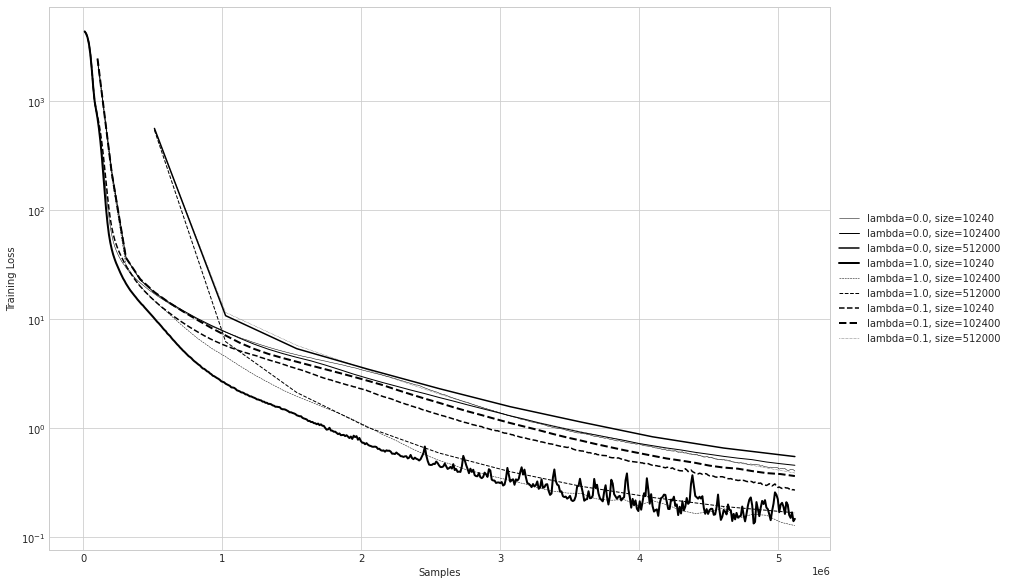

In [29]:
fig, ax = plt.subplots(figsize=(14,10))

from cycler import cycler
monochrome = (cycler('color', ['k']) * cycler('linestyle', ['-', '--', ':', '-.']) * cycler('linewidth', [0.5,1,1.5,2]))

ax.set_prop_cycle(monochrome)
for idx, ilr in enumerate(history_dict):
    train_loss_hist = history_dict[ilr]
    train_loss_values = train_loss_hist['train_loss']
    samples = [sample_sizes[idx%3] * (i+1) for i in range(epochs[idx%3])]
    ax.plot(samples, train_loss_values, label = ilr)
 
ax.set_xlabel('Samples')
ax.set_ylabel('Training Loss')
ax.set_yscale('log')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.savefig('TestSobolevTrain2.png', dpi=300, bbox_inches='tight')

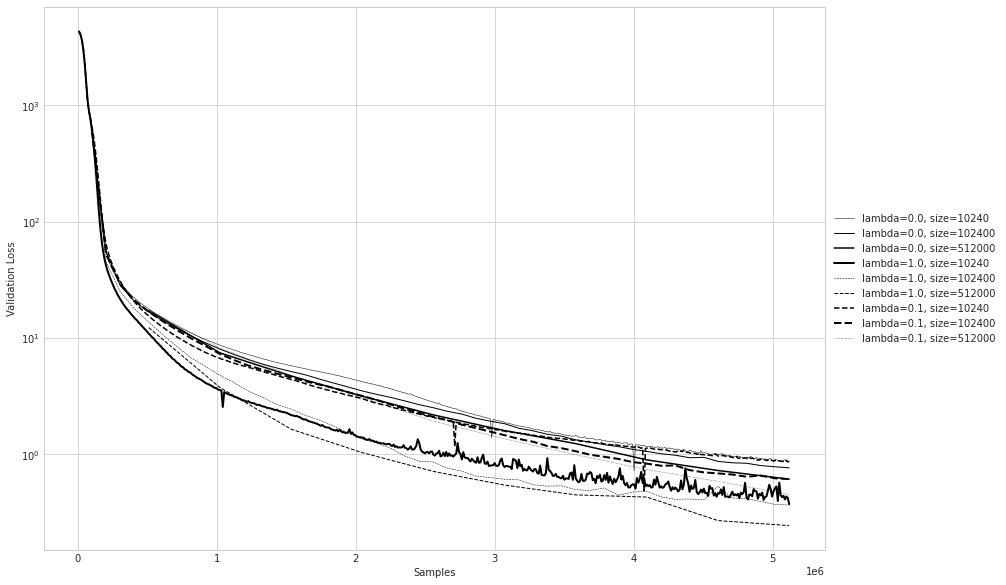

In [30]:
fig, ax = plt.subplots(figsize=(14,10))

from cycler import cycler
monochrome = (cycler('color', ['k']) * cycler('linestyle', ['-', '--', ':', '-.']) * cycler('linewidth', [0.5,1,1.5,2]))

ax.set_prop_cycle(monochrome)
for idx, ilr in enumerate(history_dict):
    train_loss_hist = history_dict[ilr]
    train_loss_values = train_loss_hist['test_loss']
    samples = [sample_sizes[idx%3] * (i+1) for i in range(epochs[idx%3])]
    ax.plot(samples, train_loss_values, label = ilr)

ax.set_xlabel('Samples')
ax.set_ylabel('Validation Loss')
ax.set_yscale('log')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.savefig('TestSobolevValid2.png', dpi=300, bbox_inches='tight')